In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
from pathlib import Path
import torch

from graph_transformer_long_range_niches.pp import sliding_window, split_adata, identify_shh_center

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data

In [48]:
DATA_PATH = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/mouse_638850_gaps.h5ad'
CFG_PATH = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/MERFISH_mouse_brain/node_cell_type/yao_gnn_ct.yaml'

In [49]:
adata = sc.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 4334174 × 483
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'barcodeCount', 'corrected_x', 'corrected_y', 'origin', 'rotation', 'section', 'animal', 'merscope', 'target_atlas_plate', 'codebook', 'min_genes', 'min_total_reads', 'min_vol', 'genes_detected', 'total_reads', 'total_blanks', 'spot_density', 'max_blank_count', 'blanks_detected', 'cell_qc', 'best.cl', 'clean_region_label', 'prob', 'avg.dist', 'avg.path.cor', 'avg.cor', 'cor.zscore', 'cluster_id', 'cluster_label', 'supertype_id_label', 'Level2_id_label', 'Level1_id_label', 'class_id_label', 'cluster_id.AIT16', 'nt_type_label', 'luster_id', 'subclass_id_label', 'He.label', 'He.cor', 'class_label', 'division_label', 'division_id_label', 'subclass_label', 'supertype_label', 'nt_type_combo_label', 'CCF_landmark', 'CCF_bin_x', 'CCF_bin_y', 'CCF_bin_z', 'structures_id', 'CCF_acronym', 'CCF_analysis', 'CCF_broad', 'cell_type', 'in_fov', '_scvi_batch', '_scvi_

In [50]:
'1015221640100370195-1' in adata.obs['sliding_window_square']

True

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


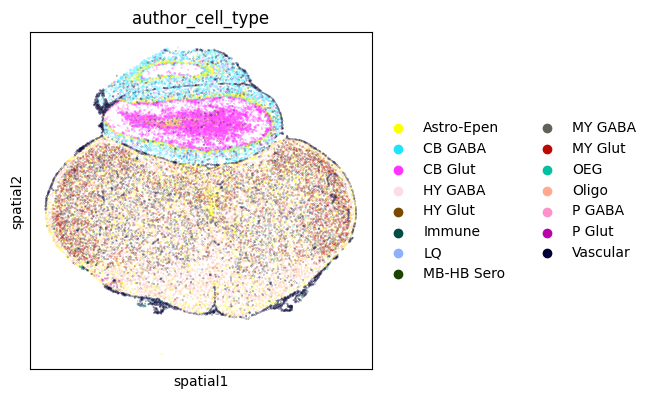

In [5]:
sq.pl.spatial_scatter(
    adata,
    spatial_key = 'spatial',
    shape=None,
    library_key='library_key', 
    library_id = ['1199650929'], 
    color="author_cell_type", #cell_type_coarse",
)

# Preprocess data

In [6]:
adata.obs['globalX'] = adata.obs['center_x']
adata.obs['globalY'] = adata.obs['center_y']

## Sliding window

In [7]:
MAX_NR_CELLS = 5000

In [8]:
del adata.obs['sliding_window_square']

In [51]:
sliding_window(
    adata,
    library_key = 'library_key',
    window_size = None,
    overlap = 0,
    max_n_cells=MAX_NR_CELLS,
    partial_window = 'merge',
    square = True,
    sliding_window_key = 'sliding_window_square',
    copy = False,
) 

In [52]:
assert {'sliding_window_square'}.issubset(adata.obs.columns), "Missing required columns in adata.obs"

In [60]:
print(adata.obs['sliding_window_square'].dtype)
print(adata.obs['sliding_window_square'].unique())

print(adata.obs['library_key'].dtype)
print(adata.obs['library_key'].unique())

category
['1199650929_12', '1199650929_18', '1199650929_13', '1199650929_11', '1199650929_14', ..., '1199651136_6', '1199651136_5', '1199651136_10', '1199651136_1', '1199651136_4']
Length: 1978
Categories (1978, object): ['1199651130_0' < '1199651136_0' < '1199650932_1' < '1199650935_1' ... '1199651033_77' < '1199651039_77' < '1199651039_78' < '1199651039_79']
category
['1199650929', '1199650932', '1199650935', '1199650938', '1199650941', ..., '1199651121', '1199651127', '1199651130', '1199651133', '1199651136']
Length: 59
Categories (59, object): ['1199650929', '1199650932', '1199650935', '1199650938', ..., '1199651127', '1199651130', '1199651133', '1199651136']


In [78]:
obj = np.array(adata.obs['library_key'])

In [79]:
torch.from_numpy(obj.astype(np.float64)).to(torch.float)
torch.from_numpy(obj.astype(np.float64)).to(torch.float)

tensor([1.1997e+09, 1.1997e+09, 1.1997e+09,  ..., 1.1997e+09, 1.1997e+09,
        1.1997e+09])

In [14]:
adata_lib_1199650929 = adata[adata.obs['library_key'] == '1199650929']

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


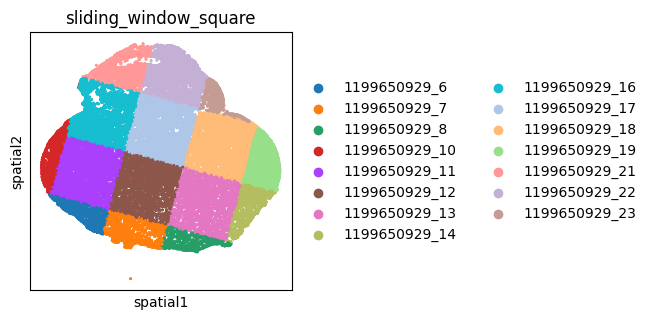

In [15]:
sq.pl.spatial_scatter(
            adata_lib_1199650929,
            color = ['sliding_window_square'],
            spatial_key = 'spatial',
            shape= None,
)

In [16]:
adata.obs_names_make_unique()

In [17]:
adata.obs_names.astype(str)

Index(['1015221640100570419', '1015221640100590598', '1015221640100820600',
       '1015221640100580476', '1015221640100580189', '1015221640100480585',
       '1015221640100570430', '1015221640100570438', '1015221640100820610',
       '1015221640100800040',
       ...
       '1018145707100080929', '1018145707200320683', '1018145707100170966',
       '1018145707100290449', '1018145707100171201', '1018145707100250222',
       '1018145707100250185', '1018145707100430302', '1018145707100430291',
       '1018145707100390249'],
      dtype='object', length=4334174)

In [18]:
for sliding_window_id in adata.obs.columns[adata.obs.columns.str.contains("sliding_window")]:
    # Calculate the size (number of cells) for each sliding window
    window_sizes = adata.obs.groupby(sliding_window_id).size()
    
    # Display the window sizes
    print(f"Statistics for {sliding_window_id}:")
    print(window_sizes.describe())  # Get a summary of the statistics (min, max, mean, etc.)
    
    # Calculate and print additional statistics
    max_cells = window_sizes.max()
    min_cells = window_sizes.min()
    mean_cells = window_sizes.mean()
    std_cells = window_sizes.std()

Statistics for sliding_window_square:
count    1978.000000
mean     2191.190091
std       851.389185
min        72.000000
25%      1628.000000
50%      2252.000000
75%      2728.250000
max      5622.000000
dtype: float64


/tmp/ipykernel_3553377/914601144.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_sizes = adata.obs.groupby(sliding_window_id).size()


## Split data

In [63]:
split_adata(adata, split_obs='library_key', val_size=0.2, test_size=0.1, seed = 40, split_key = 'split')

Test size > 0
{'counts': {'train': 2942798, 'val': 873750, 'test': 517626}, 'groups': {'train': ['1199651057', '1199650965', '1199651066', '1199651112', '1199651054', '1199651069', '1199651021', '1199650999', '1199650944', '1199650972', '1199651127', '1199651094', '1199650984', '1199651015', '1199651109', '1199651091', '1199650938', '1199651012', '1199651097', '1199651033', '1199650975', '1199650978', '1199651039', '1199650956', '1199651084', '1199651045', '1199650959', '1199651133', '1199651103', '1199650962', '1199651042', '1199651002', '1199651121', '1199651130', '1199650968', '1199650932', '1199651106', '1199651063', '1199650953', '1199651027', '1199650950'], 'val': ['1199651115', '1199651136', '1199651024', '1199650935', '1199651048', '1199651005', '1199650981', '1199651018', '1199651036', '1199651078', '1199651075'], 'test': ['1199651060', '1199650941', '1199650929', '1199651072', '1199651100', '1199651009', '1199651081']}}


AnnData object with n_obs × n_vars = 4334174 × 483
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'barcodeCount', 'corrected_x', 'corrected_y', 'origin', 'rotation', 'section', 'animal', 'merscope', 'target_atlas_plate', 'codebook', 'min_genes', 'min_total_reads', 'min_vol', 'genes_detected', 'total_reads', 'total_blanks', 'spot_density', 'max_blank_count', 'blanks_detected', 'cell_qc', 'best.cl', 'clean_region_label', 'prob', 'avg.dist', 'avg.path.cor', 'avg.cor', 'cor.zscore', 'cluster_id', 'cluster_label', 'supertype_id_label', 'Level2_id_label', 'Level1_id_label', 'class_id_label', 'cluster_id.AIT16', 'nt_type_label', 'luster_id', 'subclass_id_label', 'He.label', 'He.cor', 'class_label', 'division_label', 'division_id_label', 'subclass_label', 'supertype_label', 'nt_type_combo_label', 'CCF_landmark', 'CCF_bin_x', 'CCF_bin_y', 'CCF_bin_z', 'structures_id', 'CCF_acronym', 'CCF_analysis', 'CCF_broad', 'cell_type', 'in_fov', '_scvi_batch', '_scvi_

In [20]:
adata_test = adata[adata.obs['split'] == 'test']

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will b

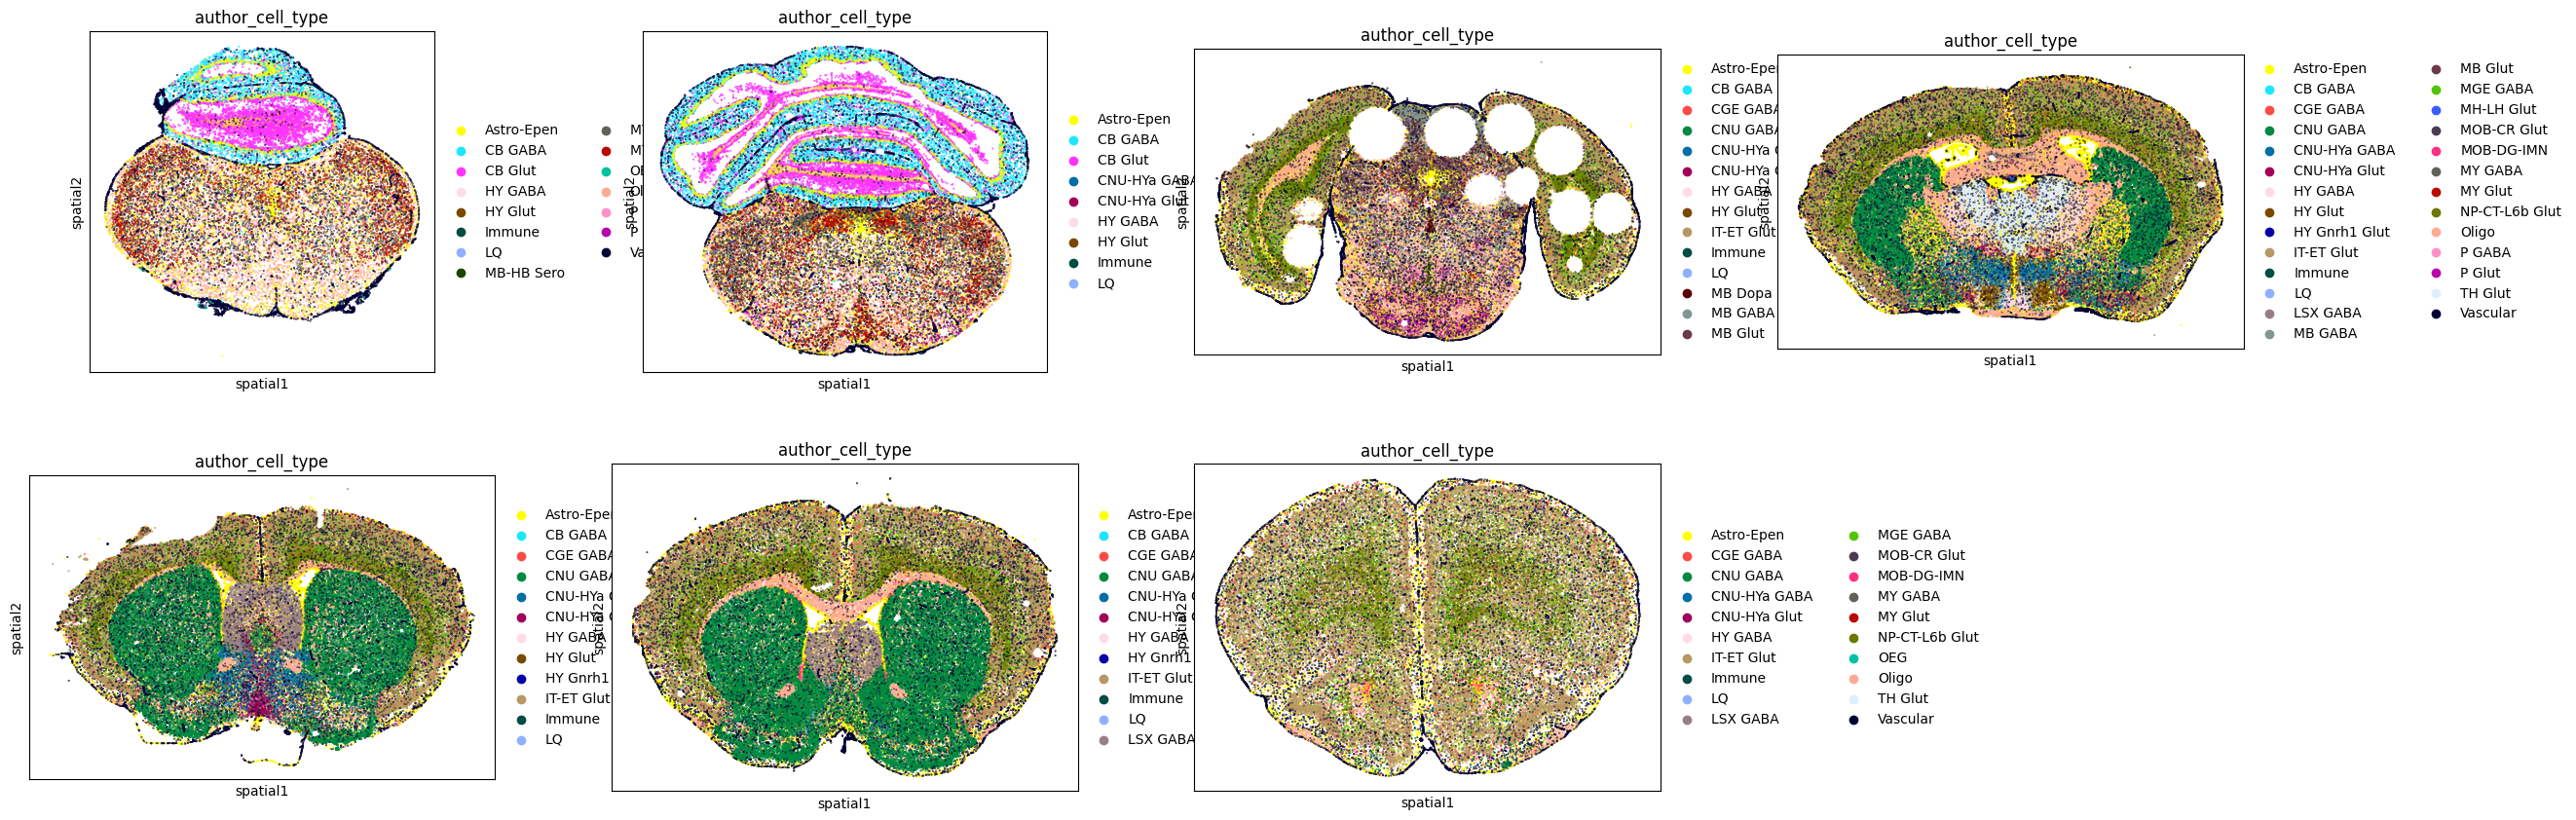

In [21]:
sq.pl.spatial_scatter(
    adata_test,
    spatial_key = 'spatial',
    shape=None,
    library_key='library_key', 
    color="author_cell_type", #cell_type_coarse",
)

In [92]:
adata.obs_names

Index(['1015221640100570419', '1015221640100590598', '1015221640100820600',
       '1015221640100580476', '1015221640100580189', '1015221640100480585',
       '1015221640100570430', '1015221640100570438', '1015221640100820610',
       '1015221640100800040',
       ...
       '1018145707100080929', '1018145707200320683', '1018145707100170966',
       '1018145707100290449', '1018145707100171201', '1018145707100250222',
       '1018145707100250185', '1018145707100430302', '1018145707100430291',
       '1018145707100390249'],
      dtype='object', length=4334174)

In [94]:
# make sure adata.obs_names are str convertable to float, necessary for geome function
str_list = [str(i) for i in list(range(0, len(adata.obs_names)))]
adata.obs_names = str_list

In [95]:
from graph_transformer_long_range_niches.pp import prepare_geome_dataset, split_adata
from graph_transformer_long_range_niches.config import load_config

cfg = load_config(CFG_PATH)
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)

Split key split already exists in adata.obs
coord_type: generic
library_key: sliding_window_square
n_neighs: 6
radius: 50
call new


/ictstr01/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


{'author_cell_type': ['Astro-Epen', 'CB GABA', 'CB Glut', 'CGE GABA', 'CNU GABA', 'CNU-HYa GABA', 'CNU-HYa Glut', 'HY GABA', 'HY Glut', 'HY Gnrh1 Glut', 'HY MM Glut', 'IT-ET Glut', 'Immune', 'LQ', 'LSX GABA', 'MB Dopa', 'MB GABA', 'MB Glut', 'MB-HB Sero', 'MGE GABA', 'MH-LH Glut', 'MOB-CR Glut', 'MOB-DG-IMN', 'MY GABA', 'MY Glut', 'NP-CT-L6b Glut', 'OEG', 'Oligo', 'P GABA', 'P Glut', 'Pineal Glut', 'TH Glut', 'Vascular']}


KeyboardInterrupt: 

In [69]:
'1015221640100370195-1' in np.array(adata.obs['sliding_window_square'])

False

In [ ]:
# TODO: Plot distribution of cell type and region in train, val and test set

In [96]:
adata.write(DATA_PATH)

In [89]:
import pandas as pd
import numpy as np

# Fake data
df = pd.DataFrame({
    "sliding_window_square": pd.Categorical(["a", "b", "c", "d"]),
    "library_key": pd.Categorical(["a", "b", "c", "d"])
})

# This will be False
print(df['sliding_window_square'])
print('a' in df['sliding_window_square'])  

print(np.unique(df['library_key']))
# This might be True
print('a' in np.unique(df['library_key']))  


0    a
1    b
2    c
3    d
Name: sliding_window_square, dtype: category
Categories (4, object): ['a', 'b', 'c', 'd']
False
['a' 'b' 'c' 'd']
True
